In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astropy.table import Table
from matplotlib.patches import Ellipse
from matplotlib.patches import Circle
import os
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import numpy
import lenstool
from lenstool.potentials import sis
lenstool.__version__

'8.10.1'

In [56]:
lt = lenstool.Lenstool()
lt.add_lens(sis(0.,0.,0.3,200))
lt.set_cosmology(73.5, 0.3, 0.7, -1)
lt.set_field(2)
lt.set_grid(2000, 1)
lt.get_lenses()

type,n,x,y,z
int64,str1,float64,float64,float64
1,1,0.0,0.0,0.3


In [84]:
from math import pi
import astropy.constants as const
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM

cosmo= FlatLambdaCDM(73.5,0.3)                     # definition of the universe (H0, z_lens)
dol=cosmo.angular_diameter_distance(0.3)         # distance between the observer and the lens
dos=cosmo.angular_diameter_distance(1.4)           # distance between the observer and the source
dls=cosmo.angular_diameter_distance_z1z2(0.3,1.4)  # distance between the lens and the source
sigma = 200 * u.km /u.s
theta = (4*pi*sigma**2*dls)/(dos*const.c**2)
theta = theta.to('m2/m2').value
theta = theta*206264.806247
print("the Einstein Radius value is:",theta) 

the Einstein Radius value is: 0.8235239694433149


In [96]:
tab = Table(names=['n','x','y','a','b','theta','z','mag'], dtype=['str',*['float',]*7]) #n is ID
tab.add_row(['Source 1', 0.5*theta, -0.5*theta, 0.14, 0.14, 0, 1.4, 20]) #a & b are semi-major axes. If a=b, circle. 
tab.meta['iref'], tab.meta['ref_ra'], tab.meta['ref_dec'] = 3, 0, 0
lt.set_sources(tab)
lt.get_sources()

n,x,y,a,b,theta,z,mag
str8,float64,float64,float64,float64,float64,float64,float64
Source 1,0.4117619847216574,-0.4117619847216574,0.14,0.14,0.0,1.4,20.0


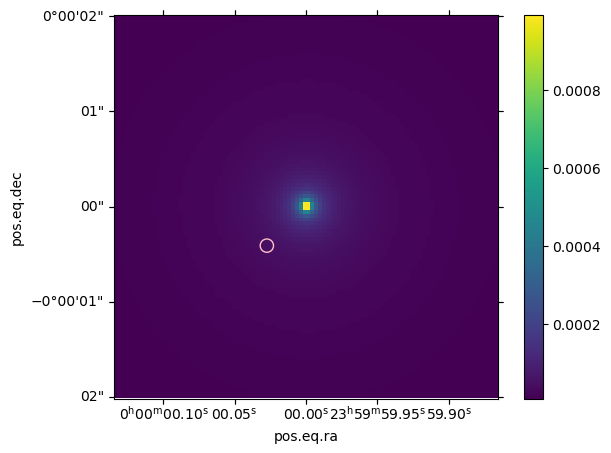

In [97]:
mass, wcs = lt.g_mass(3, 100, 0.3, 1.4)

fig = plt.figure()
ax = fig.add_axes([0.15, 0.1, 0.8, 0.8], projection=wcs) #Numbers are for graph pos
plt.imshow(mass)
plt.colorbar()

for row in lt.get_sources(): 
    ellipse = Ellipse((row['x']/3600.,row['y']/3600.), #conversion from arcsecs to degrees
                      width=row['b']/3600, 
                      height=row['a']/3600,
                      edgecolor='pink',
                      facecolor='none',
                      angle =row['theta']+90,
                      transform=plt.gca().get_transform('world')
                     )
 
    ax.add_patch(ellipse)

In [98]:
lt.e_lensing()
lt.get_images()

n,x,y,a,b,theta,z,mag
str8,float64,float64,float64,float64,float64,float64,float64
Source 1,0.9940813505711192,-0.9941002402242787,0.3379852092115795,0.14000000001723636,224.99945564657384,1.4,19.043075850929508
Source 1,-0.1705683570952143,0.1705670543605137,0.1400000000172359,0.05799488180164689,315.0002188043297,1.4,20.956845919955587


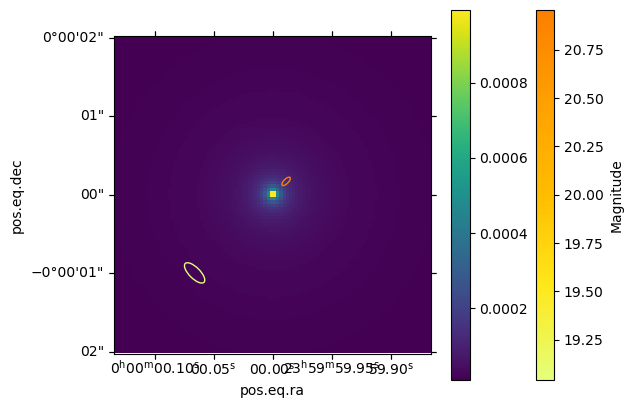

In [99]:
def plot_images():
    fig = plt.figure()
    ax = fig.add_subplot(projection=wcs)
    plt.imshow(mass)

    norm = Normalize(min(lt.get_images()['mag']), max(lt.get_images()['mag']))
    for row in lt.get_images(): 
        ellipse = Ellipse((row['x']/3600.,row['y']/3600.),
                          width=row['b']/3600,
                          height=row['a']/3600,
                          facecolor = 'none',
                          angle =row['theta'] + 90,
                          transform=plt.gca().get_transform('world')
                         )
         # Assign color to the ellipse based on the magnification

        color = cm.ScalarMappable(norm=norm, cmap = 'Wistia').to_rgba(row['mag'])
        ellipse.set_edgecolor(color)

        ax.add_patch(ellipse)

    # Creating a ScalarMappable object for colorbar
    cmap = cm.ScalarMappable(norm=norm, cmap = 'Wistia')
    cmap.set_array(tab['mag'])

    # Adding the colorbar
    colorbar = plt.colorbar(cmap, ax=ax)
    colorbar.set_label('Magnitude')
    plt.colorbar()
    plt.show()
plot_images()